In [ ]:
import re
import os
import yaml
import json
import shutil
import random
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import kagglehub
from ultralytics import YOLO
from sklearn.model_selection import train_test_split


In [ ]:
seed = 42
random.seed(seed)
np.random.seed(seed)
root = Path('/kaggle/working/lab6')
raw_dir = root / 'raw'
proc_dir = root / 'processed'
runs_dir = root / 'runs'
for p in [root, raw_dir, proc_dir, runs_dir]:
    p.mkdir(parents=True, exist_ok=True)
imgsz = 640
epochs = 20
batch = 16
device = 0


In [ ]:
# датасет: Traffic Signs Detection
kaggle_ds_path = kagglehub.dataset_download('raduoprea/traffic-signs')
dataset_root = Path(kaggle_ds_path)


Mounting files to /kaggle/input/datasets/raduoprea/traffic-signs...


In [ ]:
all_train_images = sorted(list(dataset_root.rglob('images/train/*.jpg')) + list(dataset_root.rglob('images/train/*.png')))
all_val_images = sorted(list(dataset_root.rglob('images/val/*.jpg')) + list(dataset_root.rglob('images/val/*.png')))

if len(all_train_images) == 0:
    all_train_images = sorted(list(dataset_root.rglob('train/images/*.jpg')) + list(dataset_root.rglob('train/images/*.png')))
if len(all_val_images) == 0:
    all_val_images = sorted(list(dataset_root.rglob('val/images/*.jpg')) + list(dataset_root.rglob('val/images/*.png')))

assert len(all_train_images) > 0, 'train images not found'

train_img_dir = all_train_images[0].parent

train_lbl_dir = train_img_dir.parent / 'labels'
if not train_lbl_dir.exists():
    cand = sorted(set(p.parent for p in dataset_root.rglob('train/labels/*.txt')))
    assert len(cand) > 0, 'train labels not found'
    train_lbl_dir = cand[0]

val_from_train_split = len(all_val_images) == 0

if not val_from_train_split:
    val_img_dir = all_val_images[0].parent
    val_lbl_dir = val_img_dir.parent / 'labels'
    if not val_lbl_dir.exists():
        cand = sorted(set(p.parent for p in dataset_root.rglob('val/labels/*.txt')))
        assert len(cand) > 0, 'val labels not found'
        val_lbl_dir = cand[0]

print('train_img_dir:', train_img_dir)
print('train_lbl_dir:', train_lbl_dir)
print('train images :', len(all_train_images))
print('val images src:', len(all_val_images))
print('val_from_train_split:', val_from_train_split)


train_img_dir: /kaggle/input/datasets/raduoprea/traffic-signs/Traffic Signs/train/images
train_lbl_dir: /kaggle/input/datasets/raduoprea/traffic-signs/Traffic Signs/train/labels
train images : 5209
val images src: 0
val_from_train_split: True


In [ ]:
from collections import Counter

class_counter = Counter()

def read_label_file(lbl_path):
    rows = []
    if not lbl_path.exists():
        return rows
    with open(lbl_path, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            vals = line.split()
            if len(vals) < 5:
                continue
            cls = int(float(vals[0]))
            x, y, w, h = map(float, vals[1:5])
            rows.append((cls, x, y, w, h))
    return rows

for ip in all_train_images:
    lp = train_lbl_dir / f'{ip.stem}.txt'
    rows = read_label_file(lp)
    for r in rows:
        class_counter[r[0]] += 1

selected_classes = [c for c, _ in class_counter.most_common(8)]
class_to_id = {c: i for i, c in enumerate(selected_classes)}
id_to_class = {i: str(c) for c, i in class_to_id.items()}

print('selected_classes:', selected_classes)


selected_classes: [22, 38, 40, 8, 16, 24, 25, 43]


In [ ]:
images_out = proc_dir / 'images'
labels_out = proc_dir / 'labels'
for split in ['train', 'val']:
    (images_out / split).mkdir(parents=True, exist_ok=True)
    (labels_out / split).mkdir(parents=True, exist_ok=True)


def bbox_to_rect_polygon(x, y, w, h):
    x1 = x - w / 2
    y1 = y - h / 2
    x2 = x + w / 2
    y2 = y + h / 2
    x1 = max(0.0, min(1.0, x1))
    y1 = max(0.0, min(1.0, y1))
    x2 = max(0.0, min(1.0, x2))
    y2 = max(0.0, min(1.0, y2))
    return [x1, y1, x2, y1, x2, y2, x1, y2]


def export_split(image_list, src_lbl_dir, split):
    kept = 0
    for ip in image_list:
        lp = src_lbl_dir / f'{ip.stem}.txt'
        rows = read_label_file(lp)

        seg_lines = []
        for cls, x, y, w, h in rows:
            if cls not in class_to_id:
                continue
            new_cls = class_to_id[cls]
            poly = bbox_to_rect_polygon(x, y, w, h)
            seg_lines.append(f"{new_cls} " + ' '.join([f'{v:.6f}' for v in poly]))

        if len(seg_lines) == 0:
            continue

        shutil.copy2(ip, images_out / split / ip.name)
        with open(labels_out / split / f'{ip.stem}.txt', 'w', encoding='utf-8') as f:
            f.write('\n'.join(seg_lines))
        kept += 1
    return kept

if val_from_train_split:
    train_src, val_src = train_test_split(all_train_images, test_size=0.2, random_state=seed, shuffle=True)
    train_kept = export_split(train_src, train_lbl_dir, 'train')
    val_kept = export_split(val_src, train_lbl_dir, 'val')
else:
    train_kept = export_split(all_train_images, train_lbl_dir, 'train')
    val_kept = export_split(all_val_images, val_lbl_dir, 'val')

print('train_kept:', train_kept)
print('val_kept  :', val_kept)


train_kept: 731
val_kept  : 194


In [ ]:
seg_yaml = proc_dir / 'roadsigns8_seg.yaml'
yaml_data = {
    'path': str(proc_dir),
    'train': 'images/train',
    'val': 'images/val',
    'names': {i: id_to_class[i] for i in range(len(id_to_class))}
}
with open(seg_yaml, 'w', encoding='utf-8') as f:
    yaml.safe_dump(yaml_data, f, allow_unicode=True, sort_keys=False)

print(seg_yaml)


/kaggle/working/lab6/processed/roadsigns8_seg.yaml


In [ ]:
model = YOLO('yolov8n-seg.pt')

train_res = model.train(
    data=str(seg_yaml),
    task='segment',
    imgsz=imgsz,
    epochs=epochs,
    batch=batch,
    device=device,
    workers=2,
    optimizer='AdamW',
    lr0=1e-3,
    weight_decay=5e-4,
    project=str(runs_dir),
    name='roadsigns8_seg',
    verbose=True,
    plots=True
)


Ultralytics 8.4.35 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/lab6/processed/roadsigns8_seg.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=roadsigns8_seg4, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_ma

In [ ]:
from ultralytics import YOLO

best_weights = '/kaggle/working/lab6/runs/roadsigns8_seg4/weights/best.pt'
best_model = YOLO(best_weights)

val_results = best_model.val(
    data=str(seg_yaml),
    split='val',
    imgsz=imgsz,
    batch=batch,
    device=device,
    task='segment',
    verbose=True
)

box_precision = float(val_results.box.mp)
box_recall = float(val_results.box.mr)
seg_mAP50 = float(val_results.seg.map50)
seg_mAP5095 = float(val_results.seg.map)

print('box_precision:', round(box_precision, 4))
print('box_recall:', round(box_recall, 4))
print('seg_mAP50:', round(seg_mAP50, 4))
print('seg_mAP5095:', round(seg_mAP5095, 4))


Ultralytics 8.4.35 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8n-seg summary (fused): 86 layers, 3,259,624 parameters, 0 gradients, 11.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2455.1±766.1 MB/s, size: 133.5 KB)
val: Scanning /kaggle/working/lab6/processed/labels/val.cache... 610 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 610/610 255.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 39/39 4.8it/s 8.2s0.2s
                   all        610       3078      0.792      0.678      0.772       0.59      0.822       0.63      0.729      0.464
                    22        461       2138      0.819      0.738      0.836       0.57      0.789      0.617      0.717      0.346
                    38        238        341       0.73      0.757      0.806      0.649      0.769      0.714      0.781       0.52
                    40    

In [ ]:
def yolo_seg_line_to_mask(line, H, W):
    vals = list(map(float, line.strip().split()))
    cls_id = int(vals[0])
    pts = np.array(vals[1:], dtype=np.float32).reshape(-1, 2)
    pts[:, 0] *= W
    pts[:, 1] *= H
    pts = np.round(pts).astype(np.int32)
    m = np.zeros((H, W), dtype=np.uint8)
    cv2.fillPoly(m, [pts], 1)
    return cls_id, m

def build_gt_mask_from_label(lbl_path, H, W):
    m = np.zeros((H, W), dtype=np.uint8)
    with open(lbl_path, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            _, obj = yolo_seg_line_to_mask(line, H, W)
            m = np.maximum(m, obj)
    return m

def build_pred_mask(result, H, W):
    if result.masks is None:
        return np.zeros((H, W), dtype=np.uint8)
    pm = np.zeros((H, W), dtype=np.uint8)
    masks = result.masks.data.cpu().numpy()
    for mk in masks:
        mk = (mk > 0.5).astype(np.uint8)
        mk = cv2.resize(mk, (W, H), interpolation=cv2.INTER_NEAREST)
        pm = np.maximum(pm, mk)
    return pm

def metrics_from_masks(gt, pr):
    gt = (gt > 0).astype(np.uint8)
    pr = (pr > 0).astype(np.uint8)
    tp = int(((gt == 1) & (pr == 1)).sum())
    fp = int(((gt == 0) & (pr == 1)).sum())
    fn = int(((gt == 1) & (pr == 0)).sum())
    iou = tp / (tp + fp + fn + 1e-9)
    precision = tp / (tp + fp + 1e-9)
    recall = tp / (tp + fn + 1e-9)
    l2 = float(np.sqrt(np.mean((gt.astype(np.float32) - pr.astype(np.float32)) ** 2)))
    return iou, precision, recall, l2


In [ ]:
val_img_list = sorted(list((images_out / 'val').glob('*.jpg')) + list((images_out / 'val').glob('*.png')))

ious, precs, recs, l2s = [], [], [], []
for ip in val_img_list:
    img = cv2.imread(str(ip))
    H, W = img.shape[:2]
    lbl = labels_out / 'val' / f'{ip.stem}.txt'
    gt_mask = build_gt_mask_from_label(lbl, H, W)
    pred = best_model.predict(source=str(ip), imgsz=imgsz, conf=0.25, iou=0.5, task='segment', device=device, verbose=False)[0]
    pr_mask = build_pred_mask(pred, H, W)
    iou, p, r, l2 = metrics_from_masks(gt_mask, pr_mask)
    ious.append(iou)
    precs.append(p)
    recs.append(r)
    l2s.append(l2)

val_iou = float(np.mean(ious))
val_precision = float(np.mean(precs))
val_recall = float(np.mean(recs))
val_l2 = float(np.mean(l2s))

val_iou_ge_05 = float(np.mean(np.array(ious) >= 0.5))
val_iou_ge_075 = float(np.mean(np.array(ious) >= 0.75))
val_iou_ge_09 = float(np.mean(np.array(ious) >= 0.9))

print('VAL IoU:', round(val_iou, 4))
print('VAL Precision:', round(val_precision, 4))
print('VAL Recall:', round(val_recall, 4))
print('VAL L2:', round(val_l2, 4))
print('VAL IoU>=0.5:', round(val_iou_ge_05, 4))
print('VAL IoU>=0.75:', round(val_iou_ge_075, 4))
print('VAL IoU>=0.9:', round(val_iou_ge_09, 4))


VAL IoU: 0.6996
VAL Precision: 0.7771
VAL Recall: 0.8405
VAL L2: 0.1043
VAL IoU>=0.5: 0.8148
VAL IoU>=0.75: 0.5885
VAL IoU>=0.9: 0.1656


In [ ]:
import gdown
import zipfile

photos_dir = root / 'my_photos'
photos_dir.mkdir(parents=True, exist_ok=True)

photos_url = 'https://drive.google.com/file/d/1UBnVU2EL3gTWpng3mPam_VwqwLoeigGg/view?usp=sharing'
zip_path = photos_dir / 'photos.zip'


In [ ]:
m = re.search(r'/file/d/([^/]+)', photos_url)
if m is None:
    m = re.search(r'id=([^&]+)', photos_url)
file_id = m.group(1)

gdown.download(f'https://drive.google.com/uc?id={file_id}', str(zip_path), quiet=False)

with zipfile.ZipFile(zip_path, 'r') as zf:
    zf.extractall(photos_dir)

mac_dir = photos_dir / '__MACOSX'
if mac_dir.exists():
    shutil.rmtree(mac_dir)
for p in photos_dir.rglob('._*'):
    if p.is_file():
        p.unlink()
my_images = sorted([p for p in photos_dir.rglob('*') if p.suffix.lower() in ['.heic']])

print('my_photos:', len(my_images))


Downloading...
From: https://drive.google.com/uc?id=1UBnVU2EL3gTWpng3mPam_VwqwLoeigGg
To: /kaggle/working/lab6/my_photos/photos.zip
100%|██████████| 6.95M/6.95M [00:00<00:00, 33.4MB/s]

my_photos: 10


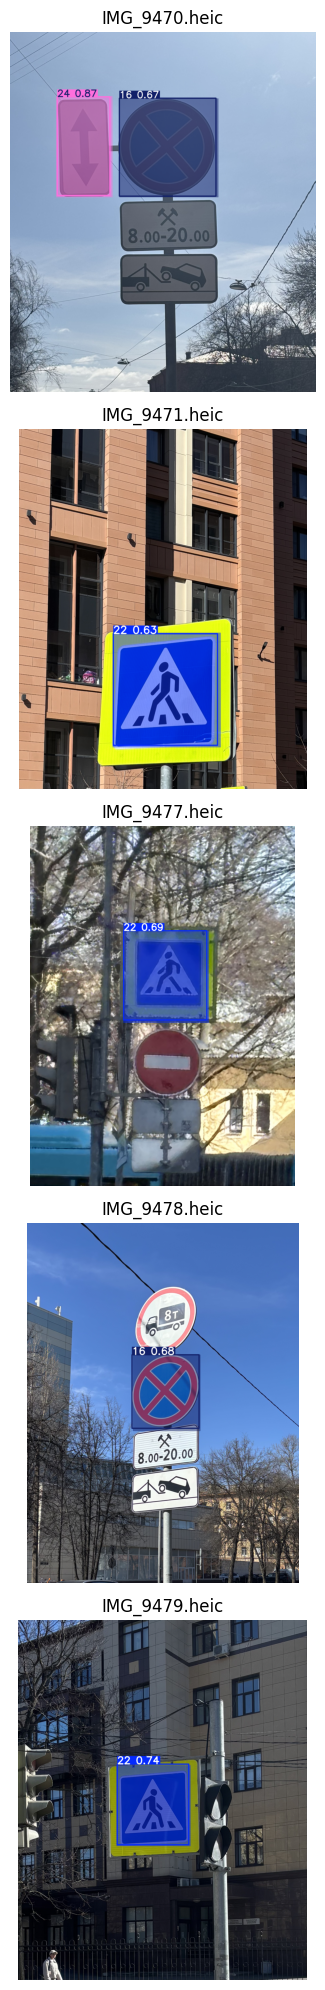

In [ ]:
excluded_ids = {str(i) for i in range(9472, 9477)} | {'9480'}
user_images = [p for p in my_images if not any(x in p.stem for x in excluded_ids)]
pred_user = best_model.predict(
    source=[str(p) for p in user_images],
    imgsz=imgsz,
    conf=0.25,
    iou=0.5,
    task='segment',
    device=device,
    verbose=False
)

n = min(10, len(pred_user))
plt.figure(figsize=(14, 4 * n))
for i in range(n):
    img_bgr = pred_user[i].plot()
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    plt.subplot(n, 1, i + 1)
    plt.imshow(img_rgb)
    plt.title(user_images[i].name)
    plt.axis('off')
plt.tight_layout()
plt.show()


In [ ]:
print('Validation metrics:')
print('IoU =', round(val_iou, 4), 'Precision =', round(val_precision, 4), 'Recall =', round(val_recall, 4), 'L2 =', round(val_l2, 4))
print('IoU>=0.5 =', round(val_iou_ge_05, 4), 'IoU>=0.75 =', round(val_iou_ge_075, 4), 'IoU>=0.9 =', round(val_iou_ge_09, 4))


Validation metrics:
IoU = 0.6996 Precision = 0.7771 Recall = 0.8405 L2 = 0.1043
IoU>=0.5 = 0.8148 IoU>=0.75 = 0.5885 IoU>=0.9 = 0.1656
